# 🦷 STS 2024 · 2D Panoramic Teeth Segmentation — **YOLO26x-seg**, semi-supervised (single RTX PRO 6000, 96 GB)

**Self-contained:** *Run All*. Reproduces the **STS2D benchmark** — an Ultralytics YOLO-seg fork
trained with a two-stage semi-supervised recipe — on the **STS24-2DXray** dataset, upgraded from the
original YOLOv8x-seg to **YOLO26x-seg** (NMS-free end-to-end) so it runs natively on RTX PRO 6000 /
Blackwell. Same data pipeline; then evaluates mask mAP + foreground Dice + FDI numbering accuracy
and saves the model, predictions and graphs.

### The benchmark, exactly
`STS2D-master` = **YOLOv8x-seg** + one STS-specific asset: `labels/Train-Unlabeled.zip`, i.e.
**pseudo-labels** (YOLO-seg polygons) for the 2 350 unlabeled X-rays. Its two experiments are:

> **Stage 1 — `train_model`**: train on **ALL** data — 30 labeled (converted from LabelMe JSON) +
> 2 350 unlabeled (provided pseudo-labels) — from COCO-seg weights.
> **Stage 2 — `finetune_model`**: continue from Stage-1 `best.pt`, training on the **labeled** data
> only, to sharpen the masks against clean ground truth.

### Task ≠ generic segmentation — the one rule that matters
FDI numbers are defined by **position in the mouth**, so:

> **No horizontal/vertical flip.** `fliplr=0.0, flipud=0.0`. A flip would move tooth `11` into the
> `21` slot while keeping the `11` label. Mosaic stays on (it transforms polygons with the pixels,
> so masks remain valid) and is closed for the final epochs.

### Classes (fixed — must match the provided pseudo-labels)
The **52 FDI codes sorted as integers**: permanent `11-18,21-28,31-38,41-48` then primary
`51-55,61-65,71-75,81-85` → indices `0-51`. Verified: `18`=7, `28`=15, `38`=23, `48`=31, `51`=32.

## 1 · Environment
`nvidia-smi`, then install a recent **ultralytics** (ships **YOLO26**) + `gdown` for the dataset. The
Vast.ai / cloud image already ships torch+CUDA. `yolo26x-seg.pt` auto-downloads on first use.

> STS2D-master pins ultralytics **8.0.45** (torch 1.x) — that release predates Blackwell **and**
> predates YOLO26, so it cannot run on an RTX PRO 6000. We install a current build, which both
> supports Blackwell and provides **YOLO26x-seg** (NMS-free). The data pipeline and semi-supervised
> recipe are unchanged. `PIN_OLD_ULTRALYTICS` in §2 is only for pre-Blackwell hardware (and forces
> the original YOLOv8x-seg, since 8.0.45 has no YOLO26).

In [1]:
!nvidia-smi

Thu Jul  9 02:41:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    On  |   00000000:01:00.0 Off |                  Off |
| 30%   28C    P8             13W /  600W |       2MiB /  97887MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import sys
PIN_OLD_ULTRALYTICS = False   # True -> pip install ultralytics==8.0.45 (only on pre-Blackwell GPUs)
!{sys.executable} -m pip install --upgrade pip
if PIN_OLD_ULTRALYTICS:
    !{sys.executable} -m pip install "ultralytics==8.0.45"
    !{sys.executable} -m pip install -U gdown opencv-python-headless pandas matplotlib pyyaml shapely
else:
    !{sys.executable} -m pip install -U ultralytics gdown opencv-python-headless pandas matplotlib pyyaml shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 53.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 111.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 107.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 112.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.6/837.6 kB 81.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 111.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22/22 [ultralytics] [ultralytics]n]headless]


In [3]:
import os, json, glob, random, shutil, gc, time, datetime, re, hashlib, zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

import ultralytics
print("ultralytics", ultralytics.__version__,
      "| Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print("  GPU", i, torch.cuda.get_device_name(i),
          f"{torch.cuda.get_device_properties(i).total_memory/1024**3:.0f} GB")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics 8.4.90 | Torch: 2.12.0+cu130 | CUDA: True
  GPU 0 NVIDIA RTX PRO 6000 Blackwell Workstation Edition 95 GB


## 2 · Configuration — edit this one cell
`DATA_GDRIVE_URL` is the STS24-2DXray dataset; `PSEUDO_GDRIVE_URL` is the STS2D-master pseudo-label
archive (auto-downloaded). Without pseudo-labels, Stage 1 degrades to labeled-only (still runs, but
it is no longer the semi-supervised benchmark).

> **`SINGLE_CLASS_TOOTH`** picks the task. `True` = pure **tooth segmentation** (all teeth → one
> class; the STS-2D Dice metric) — easier, faster, lighter, and horizontal flips become safe
> augmentation. `False` = full **52-class FDI numbering**. The 52-class pseudo-labels are used
> either way — in tooth mode their class index is remapped to `0` on the fly.

In [4]:
# ---- data sources -----------------------------------------------------------
DATA_GDRIVE_URL   = "https://drive.google.com/file/d/1DIX3mPjMt-ye5591JfB7fF_K9VRmNmvc/view?usp=drive_link"
PSEUDO_GDRIVE_URL = "https://drive.google.com/file/d/1aLOsroS2MjgItoAYu1TbE_F9nGudwt9m/view?usp=drive_link"  # pseudo-label zip (STS2D-master/labels/Train-Unlabeled.zip)
PSEUDO_LABELS_ZIP = "Train-Unlabeled.zip"   # local fallback if you upload the zip instead of gdown

# ---- FDI class scheme (FIXED: 52 codes sorted as integers — matches the pseudo-labels) ------
QUADRANTS = [range(11,19), range(21,29), range(31,39), range(41,49),      # permanent
             range(51,56), range(61,66), range(71,76), range(81,86)]      # primary
FDI_CODES = [str(c) for q in QUADRANTS for c in q]        # '11','12',...,'85'  -> indices 0..51
FDI_IDX   = {n: i for i, n in enumerate(FDI_CODES)}
assert len(FDI_CODES) == 52, len(FDI_CODES)

# ---- TASK MODE --------------------------------------------------------------
# True  -> collapse ALL teeth into ONE class "tooth": pure tooth segmentation (the STS-2D Dice
#          metric). Easier + faster + lighter, and horizontal flips become SAFE (auto-enabled
#          below). Numbering (exact-FDI/quadrant) metrics are skipped — there's nothing to number.
# False -> full 52-class FDI numbering (position-sensitive; flips forced OFF).
SINGLE_CLASS_TOOTH = True

if SINGLE_CLASS_TOOTH:
    CLASSES = ["tooth"]
    def label_index(nm):    # every valid FDI code -> the single "tooth" class 0
        return 0 if nm in FDI_IDX else None
else:
    CLASSES = FDI_CODES
    def label_index(nm):
        return FDI_IDX.get(nm)
NUM_CLASSES = len(CLASSES)
CLS_IDX = {n: i for i, n in enumerate(CLASSES)}

# ---- leak-free split of the LABELED set (Testset masks are hidden; we hold out from labeled) --
SPLIT_FRACS = {"train": 0.70, "val": 0.15, "test": 0.15}

# ---- semi-supervised two-stage recipe (STS2D) -------------------------------
SEMI_SUPERVISED = True          # Stage 1 uses unlabeled + pseudo-labels; else labeled-only
# STS2D-master's benchmark is YOLOv8x-seg; we bump the detector to the newer **YOLO26x-seg**
# (NMS-free end-to-end) so it runs natively on RTX PRO 6000 / Blackwell with current ultralytics.
# The data pipeline, 52-class FDI scheme and pseudo-labels are unchanged.
# Fallback: if yolo26x-seg.pt is not yet in your ultralytics build, set "yolov8x-seg.pt".
# Single-class tooth mode? you can safely drop to a lighter/faster head: yolo26l-seg.pt / yolo26m-seg.pt.
SEG_MODEL       = "yolo26l-seg.pt"
IMGSZ           = 960          # panoramic X-rays are wide/high-res; 1024 keeps small tooth detail
BATCH           = 16           # OOM? lower to 8/4. (or set -1 for auto)
EPOCHS_STAGE1   = 100          # train_model    (all data)
EPOCHS_STAGE2   = 40           # finetune_model (labeled only)
OPTIMIZER       = "auto"
SAVE_EVERY_EPOCH = True         # save an epoch-N checkpoint every epoch (best/last always saved)

# Augmentation. Horizontal flip is SAFE in single-class tooth mode (a flipped tooth is still a
# tooth) -> auto-enabled; in 52-class FDI mode it is forced OFF (positional labels). Vertical flip
# never makes sense for an upright panoramic, so flipud stays 0 either way.
_FLIPLR = 0.5 if SINGLE_CLASS_TOOTH else 0.0
AUG = dict(
    fliplr=_FLIPLR, flipud=0.0,             # <-- task-specific: 0.5 (tooth-only) vs 0.0 (FDI)
    mosaic=1.0, close_mosaic=15,            # mosaic transforms polygons correctly (masks stay valid)
    degrees=0.0, translate=0.05, scale=0.3,
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.3,        # X-rays are grayscale: brightness only, no hue/sat
    mixup=0.0, copy_paste=0.0,
)

# auto-fallback: 8.0.45 (the pinned old build) has no YOLO26 -> use the original YOLOv8x-seg
if SEG_MODEL.startswith("yolo26") and tuple(int(x) for x in ultralytics.__version__.split(".")[:2]) < (8, 3):
    print(f"!! ultralytics {ultralytics.__version__} has no YOLO26 -> falling back to yolov8x-seg.pt")
    SEG_MODEL = "yolov8x-seg.pt"

WORK = os.path.abspath("sts2d_seg_run")
os.makedirs(WORK, exist_ok=True)
print(f"TASK: {'single-class TOOTH segmentation' if SINGLE_CLASS_TOOTH else '52-class FDI numbering'} "
      f"({NUM_CLASSES} class{'es' if NUM_CLASSES>1 else ''})")
print(f"{SEG_MODEL} @ imgsz {IMGSZ}, batch {BATCH} | Stage1 {EPOCHS_STAGE1}ep, Stage2 {EPOCHS_STAGE2}ep")
print("semi-supervised:", SEMI_SUPERVISED, "| optimizer", OPTIMIZER)
print(f"Augmentation (fliplr={AUG['fliplr']}):", AUG)
print("WORK =", WORK)

TASK: single-class TOOTH segmentation (1 class)
yolo26l-seg.pt @ imgsz 960, batch 16 | Stage1 100ep, Stage2 40ep
semi-supervised: True | optimizer auto
Augmentation (fliplr=0.5): {'fliplr': 0.5, 'flipud': 0.0, 'mosaic': 1.0, 'close_mosaic': 15, 'degrees': 0.0, 'translate': 0.05, 'scale': 0.3, 'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.3, 'mixup': 0.0, 'copy_paste': 0.0}
WORK = /sts2d_seg_run


## 3 · Download STS24-2DXray (gdown) and locate the splits
Expected layout after extraction: `…/Train-Labeled/{Images,Masks}`, `…/Train-Unlabeled/*.jpg`,
`…/Validation-Public/*.jpg`, `…/Testset/{Images,Masks}` (Testset masks are usually held out).

In [5]:
import gdown
DL = os.path.join(WORK, "download")
os.makedirs(DL, exist_ok=True)

def gdrive_fetch(url, out_name):
    out = os.path.join(DL, out_name)
    if not os.path.exists(out):
        gdown.download(url=url, output=out, quiet=False)
    return out

def maybe_unzip(path, dest):
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as z: z.extractall(dest)
        return True
    return False

archive = gdrive_fetch(DATA_GDRIVE_URL, "STS24-2DXray.zip")
DATA_ROOT_PARENT = os.path.join(DL, "STS24-2DXray_extracted")
os.makedirs(DATA_ROOT_PARENT, exist_ok=True)
if not maybe_unzip(archive, DATA_ROOT_PARENT):
    # already a folder / tar — leave as-is and search from DL
    DATA_ROOT_PARENT = DL

def find_data_root(base):
    for r, dirs, _ in os.walk(base):
        if "Train-Labeled" in dirs:
            return r
    return base
DATA_ROOT = find_data_root(DATA_ROOT_PARENT)

LAB_IMG = os.path.join(DATA_ROOT, "Train-Labeled", "Images")
LAB_MSK = os.path.join(DATA_ROOT, "Train-Labeled", "Masks")
UNLAB   = os.path.join(DATA_ROOT, "Train-Unlabeled")
VALPUB  = os.path.join(DATA_ROOT, "Validation-Public")
print("DATA_ROOT =", DATA_ROOT)
for nm, p in [("labeled images", LAB_IMG), ("labeled masks", LAB_MSK),
              ("unlabeled", UNLAB), ("validation-public", VALPUB)]:
    n = len(glob.glob(os.path.join(p, "*"))) if os.path.isdir(p) else 0
    print(f"  {nm:18}: {n:5d}  ({p})")
assert os.path.isdir(LAB_IMG) and os.path.isdir(LAB_MSK), "Train-Labeled/{Images,Masks} not found"

Downloading...
From (original): https://drive.google.com/uc?id=1DIX3mPjMt-ye5591JfB7fF_K9VRmNmvc
From (redirected): https://drive.google.com/uc?id=1DIX3mPjMt-ye5591JfB7fF_K9VRmNmvc&confirm=t&uuid=61cc53c0-ffe4-41b7-b24d-9e0d1c1e6f56
To: /sts2d_seg_run/download/STS24-2DXray.zip
100%|██████████| 1.12G/1.12G [00:17<00:00, 65.5MB/s]


DATA_ROOT = /sts2d_seg_run/download/STS24-2DXray_extracted/STS24-2DXray
  labeled images    :    30  (/sts2d_seg_run/download/STS24-2DXray_extracted/STS24-2DXray/Train-Labeled/Images)
  labeled masks     :    30  (/sts2d_seg_run/download/STS24-2DXray_extracted/STS24-2DXray/Train-Labeled/Masks)
  unlabeled         :  2350  (/sts2d_seg_run/download/STS24-2DXray_extracted/STS24-2DXray/Train-Unlabeled)
  validation-public :    20  (/sts2d_seg_run/download/STS24-2DXray_extracted/STS24-2DXray/Validation-Public)


In [6]:
# ---- pseudo-labels for the unlabeled set (STS2D-master/labels/Train-Unlabeled.zip) ----------
PSEUDO_DIR = os.path.join(WORK, "pseudo_labels")
os.makedirs(PSEUDO_DIR, exist_ok=True)
pseudo_src = None
if PSEUDO_GDRIVE_URL:
    pseudo_src = gdrive_fetch(PSEUDO_GDRIVE_URL, "pseudo_labels.zip")
elif PSEUDO_LABELS_ZIP and os.path.exists(PSEUDO_LABELS_ZIP):
    pseudo_src = PSEUDO_LABELS_ZIP

PSEUDO_TXT = {}
if pseudo_src and zipfile.is_zipfile(pseudo_src):
    with zipfile.ZipFile(pseudo_src) as z:
        for n in z.namelist():
            if n.endswith(".txt"):
                stem = os.path.splitext(os.path.basename(n))[0]
                PSEUDO_TXT[stem] = z.read(n).decode()
    # sanity: pseudo-label class indices must fit the 52-class FDI scheme (validated even in
    # single-class mode, where they are later remapped to 0)
    mx = max((int(ln.split()[0]) for t in PSEUDO_TXT.values()
              for ln in t.strip().splitlines() if ln.strip()), default=-1)
    print(f"pseudo-labels loaded: {len(PSEUDO_TXT)} files | max class idx {mx} (must be < 52)")
    assert mx < 52, "pseudo-label class index exceeds the 52-class FDI scheme — wrong archive?"
else:
    print("!! No pseudo-labels found. Stage 1 will fall back to labeled-only.")
    if SEMI_SUPERVISED:
        print("   -> set PSEUDO_LABELS_ZIP / PSEUDO_GDRIVE_URL to run the real semi-supervised benchmark.")

Downloading...
From: https://drive.google.com/uc?id=1aLOsroS2MjgItoAYu1TbE_F9nGudwt9m
To: /sts2d_seg_run/download/pseudo_labels.zip
100%|██████████| 13.0M/13.0M [00:00<00:00, 20.5MB/s]


pseudo-labels loaded: 2350 files | max class idx 51 (must be < 52)


## 4 · Convert LabelMe JSON → YOLO-seg and assemble the two training sets
Each labeled mask is LabelMe polygon JSON (`shapes[*].points`, `label`=FDI code). We normalize the
polygons and write `cls x1 y1 x2 y2 …` (the YOLO-seg format the pseudo-labels already use). Layout:

```
CLEAN/images/{train_all,train_lab,val,test}/…   CLEAN/labels/{train_all,train_lab,val,test}/…
```
* **train_all** = labeled-train + all unlabeled (pseudo) → `data_all.yaml`  (Stage 1)
* **train_lab** = labeled-train only                     → `data_labeled.yaml` (Stage 2, + val/test)

In [7]:
def labelme_to_yolo_lines(js):
    W, H = js["imageWidth"], js["imageHeight"]
    lines = []
    for sh in js.get("shapes", []):
        if sh.get("shape_type", "polygon") != "polygon":
            continue
        nm = str(sh["label"]).strip()
        ci = label_index(nm)                 # FDI idx, or 0 in single-class mode, or None if unknown
        if ci is None:
            continue
        pts = sh["points"]
        if len(pts) < 3:
            continue
        flat = []
        for x, y in pts:
            flat.append(f"{min(max(x/W,0),1):.6f}")
            flat.append(f"{min(max(y/H,0),1):.6f}")
        lines.append(f"{ci} " + " ".join(flat))
    return lines, W, H

def remap_pseudo(txt):
    # single-class mode: rewrite every pseudo-label class index to 0 ("tooth")
    if not SINGLE_CLASS_TOOTH:
        return txt.strip()
    out = []
    for ln in txt.strip().splitlines():
        p = ln.split()
        if p:
            p[0] = "0"; out.append(" ".join(p))
    return "\n".join(out)

# index labeled photos by stem
lab_records = {}   # stem -> (image_path, json_path)
for jp in sorted(glob.glob(os.path.join(LAB_MSK, "*.json"))):
    stem = os.path.basename(jp).replace("_Mask.json", "").replace(".json", "")
    cands = glob.glob(os.path.join(LAB_IMG, stem + ".*"))
    if cands:
        lab_records[stem] = (cands[0], jp)
print("labeled photos with image+json:", len(lab_records))

# ---- stratified-by-presence split of the labeled photos (every split sees teeth) ------------
stems = sorted(lab_records)
rng = random.Random(SEED); rng.shuffle(stems)
n = len(stems)
n_tr = int(round(SPLIT_FRACS["train"] * n)); n_va = int(round(SPLIT_FRACS["val"] * n))
split_of = {}
for i, s in enumerate(stems):
    split_of[s] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")
print("labeled split:", Counter(split_of.values()))

CLEAN = os.path.join(WORK, "dataset_sts2d_seg")
if os.path.exists(CLEAN): shutil.rmtree(CLEAN)
SUBSETS = ["train_all", "train_lab", "val", "test"]
for s in SUBSETS:
    os.makedirs(os.path.join(CLEAN, "images", s), exist_ok=True)
    os.makedirs(os.path.join(CLEAN, "labels", s), exist_ok=True)

def place(img_path, lines, subset, stem):
    ext = os.path.splitext(img_path)[1]
    shutil.copy2(img_path, os.path.join(CLEAN, "images", subset, stem + ext))
    with open(os.path.join(CLEAN, "labels", subset, stem + ".txt"), "w") as f:
        f.write("\n".join(lines))

counts = {s: [0, 0] for s in SUBSETS}   # [images, instances]
# labeled -> val/test, and labeled-train -> BOTH train_lab and train_all
for stem, (img_path, jp) in lab_records.items():
    lines, _, _ = labelme_to_yolo_lines(json.load(open(jp)))
    sp = split_of[stem]
    targets = {"val": ["val"], "test": ["test"], "train": ["train_lab", "train_all"]}[sp]
    for t in targets:
        place(img_path, lines, t, stem)
        counts[t][0] += 1; counts[t][1] += len(lines)

# unlabeled + pseudo-labels -> train_all only
if SEMI_SUPERVISED and PSEUDO_TXT:
    for ip in sorted(glob.glob(os.path.join(UNLAB, "*.jpg"))):
        stem = os.path.splitext(os.path.basename(ip))[0]
        if stem not in PSEUDO_TXT:
            continue
        txt = remap_pseudo(PSEUDO_TXT[stem])
        shutil.copy2(ip, os.path.join(CLEAN, "images", "train_all", stem + ".jpg"))
        with open(os.path.join(CLEAN, "labels", "train_all", stem + ".txt"), "w") as f:
            f.write(txt)
        counts["train_all"][0] += 1
        counts["train_all"][1] += sum(1 for ln in txt.splitlines() if ln.strip())

import yaml
def write_yaml(name, train_subset, with_test):
    d = {"path": CLEAN, "train": f"images/{train_subset}", "val": "images/val",
         "names": {i: c for i, c in enumerate(CLASSES)}}
    if with_test: d["test"] = "images/test"
    p = os.path.join(CLEAN, name)
    with open(p, "w") as f: yaml.safe_dump(d, f, sort_keys=False)
    return p

DATA_ALL = write_yaml("data_all.yaml",     "train_all", with_test=True)
DATA_LAB = write_yaml("data_labeled.yaml", "train_lab", with_test=True)
for s in SUBSETS:
    print(f"[{s:9}] images={counts[s][0]:5d} instances={counts[s][1]:6d}")
print("data_all.yaml   ->", DATA_ALL)
print("data_labeled.yaml ->", DATA_LAB)

labeled photos with image+json: 30
labeled split: Counter({'train': 21, 'test': 5, 'val': 4})
[train_all] images= 2371 instances= 69618
[train_lab] images=   21 instances=   571
[val      ] images=    4 instances=   135
[test     ] images=    5 instances=   153
data_all.yaml   -> /sts2d_seg_run/dataset_sts2d_seg/data_all.yaml
data_labeled.yaml -> /sts2d_seg_run/dataset_sts2d_seg/data_labeled.yaml


### 4b · QA guard — catch a broken export before an expensive train
Hard-fails if a split has **no images** or the class scheme mis-aligns. Missing *primary* teeth
(51-85) in a small adult panoramic set is normal → reported as a warning, not a failure.

In [8]:
def subset_cls_counts(subset):
    cc = Counter()
    for tp in glob.glob(os.path.join(CLEAN, "labels", subset, "*.txt")):
        for ln in open(tp):
            if ln.strip(): cc[int(ln.split()[0])] += 1
    return cc
cc = {s: subset_cls_counts(s) for s in SUBSETS}
train_key = "train_all" if (SEMI_SUPERVISED and PSEUDO_TXT) else "train_lab"
missing_train = [CLASSES[i] for i in range(NUM_CLASSES) if cc[train_key].get(i, 0) == 0]
print("QA | classes absent from", train_key, ":", missing_train or "none")
print("QA | val instances:", sum(cc["val"].values()), "| test instances:", sum(cc["test"].values()))
for s in SUBSETS:
    assert counts[s][0] > 0 or s == "train_all", f"subset {s} has no images"
assert sum(cc["val"].values()) > 0 and sum(cc["test"].values()) > 0, "val/test empty — check split"
if missing_train:
    print("   (note: missing entries are usually primary teeth 51-85, biologically absent in adults)")
print("QA passed: images present in every split; class indices in-range.")

QA | classes absent from train_all : none
QA | val instances: 135 | test instances: 153
QA passed: images present in every split; class indices in-range.


## 5 · EDA — class balance, teeth/image, mask size
Dense numbering (~28-32 teeth/image); rarest are third molars (18/28/38/48) and any primary teeth.
Read straight from the YOLO-seg polygon files (area via the shoelace formula on normalized points).

In [9]:
def poly_area_norm(coords):
    x = coords[0::2]; y = coords[1::2]
    return 0.5 * abs(sum(x[i]*y[(i+1)%len(x)] - x[(i+1)%len(x)]*y[i] for i in range(len(x))))

def read_seg(subset):
    cls = Counter(); per_img = []; areas = []
    for tp in glob.glob(os.path.join(CLEAN, "labels", subset, "*.txt")):
        rows = [ln.split() for ln in open(tp) if ln.strip()]
        per_img.append(len(rows))
        for r in rows:
            cls[int(r[0])] += 1
            areas.append(poly_area_norm([float(v) for v in r[1:]]))
    return dict(n=len(glob.glob(os.path.join(CLEAN, "images", subset, "*"))),
                cls=cls, tpi=per_img, areas=areas)

show = ["train_lab", "val", "test"] + (["train_all"] if SEMI_SUPERVISED and PSEUDO_TXT else [])
eda = {s: read_seg(s) for s in show}
grand = sum(sum(eda[s]["cls"].values()) for s in ["train_lab", "val", "test"])
print(f"{'FDI':<6}" + "".join(f"{s:>11}" for s in show) + f"{'TOT(lab)':>10}")
for i, nm in enumerate(CLASSES):
    tot = sum(eda[s]['cls'].get(i, 0) for s in ['train_lab','val','test'])
    print(f"{nm:<6}" + "".join(f"{eda[s]['cls'].get(i,0):>11}" for s in show) + f"{tot:>10}")
for s in show:
    b = eda[s]['tpi']
    print(f"[{s}] images={eda[s]['n']} teeth/img={sum(b)/max(len(b),1):.2f} (max {max(b) if b else 0})")

FDI     train_lab        val       test  train_all  TOT(lab)
tooth         571        135        153      69618       859
[train_lab] images=21 teeth/img=27.19 (max 48)
[val] images=4 teeth/img=33.75 (max 47)
[test] images=5 teeth/img=30.60 (max 47)
[train_all] images=2371 teeth/img=29.36 (max 51)


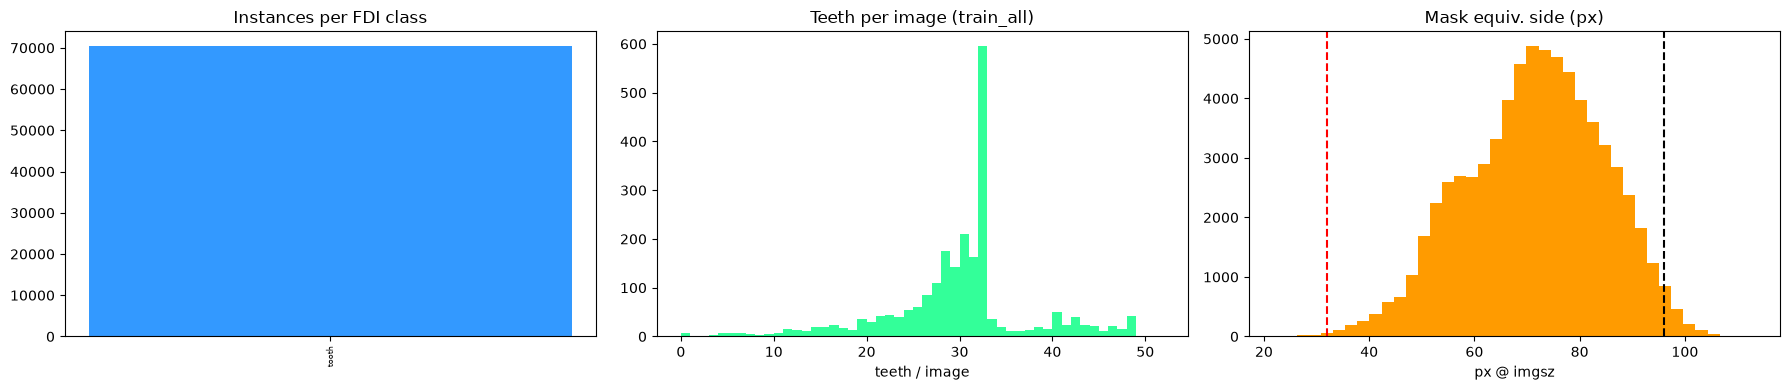

In [10]:
ref = "train_all" if (SEMI_SUPERVISED and PSEUDO_TXT) else "train_lab"
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
tot = [sum(eda[s]['cls'].get(i, 0) for s in show) for i in range(NUM_CLASSES)]
ax[0].bar(range(NUM_CLASSES), tot, color="#3399ff")
ax[0].set_xticks(range(NUM_CLASSES)); ax[0].set_xticklabels(CLASSES, rotation=90, fontsize=6)
ax[0].set_title("Instances per FDI class")
mx = max(eda[ref]['tpi']) if eda[ref]['tpi'] else 1
ax[1].hist(eda[ref]['tpi'], bins=range(0, mx + 2), color="#33ff99")
ax[1].set_title(f"Teeth per image ({ref})"); ax[1].set_xlabel("teeth / image")
px_side = np.sqrt(np.array(eda[ref]['areas'])) * IMGSZ
ax[2].hist(px_side, bins=40, color="#ff9b00")
ax[2].axvline(32, color="r", ls="--"); ax[2].axvline(96, color="k", ls="--")
ax[2].set_title("Mask equiv. side (px)"); ax[2].set_xlabel("px @ imgsz")
plt.tight_layout(); plt.savefig(os.path.join(WORK, "eda_overview.png"), dpi=110); plt.show()

## 6 · Augmentation sanity-check — flip behaviour depends on the task
Left: a labeled X-ray with its polygon masks. Middle: a horizontal flip. In **52-class FDI mode**
that flip reverses the arch order (tooth `11` lands in the `21` slot) while keeping the label, so
`fliplr=0.0`. In **single-class tooth mode** a flipped tooth is still a tooth, so `fliplr=0.5` is
safe, free augmentation (auto-enabled). Mosaic (not shown) is always safe — it transforms polygons
along with the pixels.

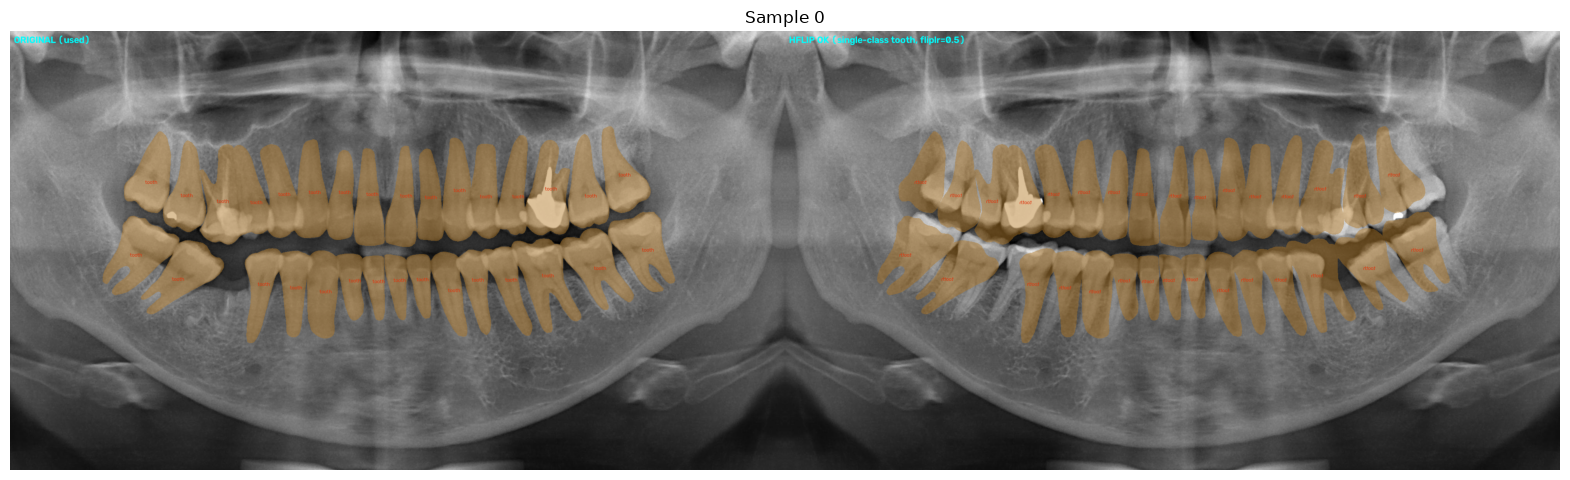

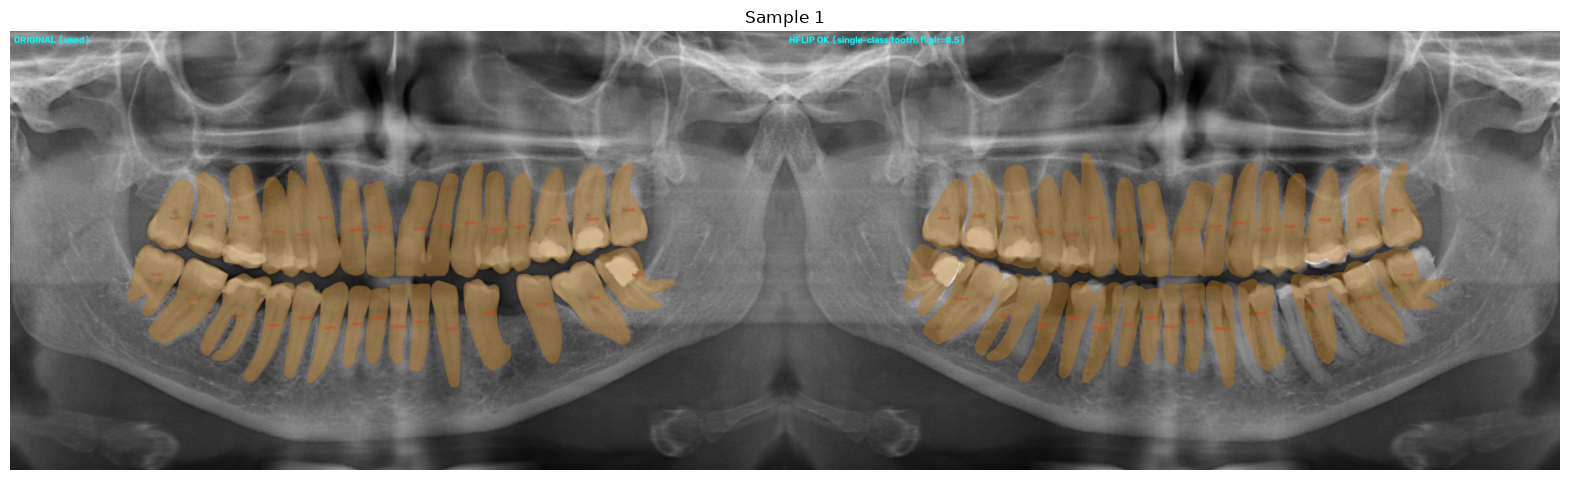

Single-class tooth mode: a flipped tooth is still a tooth -> fliplr=0.5 is safe, free augmentation.


In [11]:
CMAP = (plt.get_cmap("tab20")(np.linspace(0, 1, 20))[:, :3] * 255).astype(int)
def color_for(cid): return tuple(int(v) for v in CMAP[cid % 20])

def load_seg(subset, img_path):
    img = cv2.imread(img_path); H, W = img.shape[:2]
    lp = os.path.join(CLEAN, "labels", subset, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
    polys = []
    for ln in open(lp):
        if not ln.strip(): continue
        v = ln.split(); c = int(v[0]); pts = np.array(v[1:], float).reshape(-1, 2)
        pts[:, 0] *= W; pts[:, 1] *= H
        polys.append((c, pts.astype(np.int32)))
    return img, polys

def draw_seg(img, polys, flip=False):
    vis = img.copy(); W = vis.shape[1]; overlay = vis.copy()
    for c, pts in polys:
        p = pts.copy()
        if flip: p[:, 0] = W - p[:, 0]
        cv2.fillPoly(overlay, [p], color_for(c))
        m = p.mean(0).astype(int)
        cv2.putText(vis, CLASSES[c], (int(m[0])-8, int(m[1])),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 1)
    out = cv2.addWeighted(overlay, 0.45, vis, 0.55, 0)
    return np.ascontiguousarray(out[:, ::-1]) if flip else out

mid_txt = (f"HFLIP OK (single-class tooth, fliplr={AUG['fliplr']})" if SINGLE_CLASS_TOOTH
           else "HFLIP keeps label = WRONG (fliplr=0)")
imgs = sorted(glob.glob(os.path.join(CLEAN, "images", "val", "*")))[:2]
for k, ip in enumerate(imgs):
    img, polys = load_seg("val", ip)
    a = draw_seg(img, polys); b = draw_seg(img, polys, flip=True)
    for im, txt in [(a, "ORIGINAL (used)"), (b, mid_txt)]:
        cv2.putText(im, txt, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
    tiles = [cv2.cvtColor(x, cv2.COLOR_BGR2RGB) for x in (a, b)]
    plt.figure(figsize=(20, 6)); plt.imshow(np.hstack(tiles)); plt.axis("off")
    plt.title(f"Sample {k}"); plt.show()
if SINGLE_CLASS_TOOTH:
    print(f"Single-class tooth mode: a flipped tooth is still a tooth -> fliplr={AUG['fliplr']} is safe, free augmentation.")
else:
    print("FDI mode: training uses fliplr=0.0/flipud=0.0; a flip would scramble positional numbers.")

## 7 · Stage 1 — `train_model` (ALL data, YOLO26x-seg)
Trains on labeled-train + 2 350 pseudo-labeled unlabeled X-rays, from COCO-seg weights. A per-epoch
callback prints a compact report; `best.pt`/`last.pt` are written **every epoch** (plus an
`epoch{N}.pt` when `SAVE_EVERY_EPOCH`). Outputs go under `WORK/sts2d/stage1_train_all`.

> OOM? lower `BATCH` (16 → 8 → 4) or set `BATCH=-1` for auto.

In [12]:
from ultralytics import YOLO
SEG_OUT = os.path.join(WORK, "sts2d")

def attach_epoch_report(model, tag):
    hist = []
    def on_fit_epoch_end(trainer):
        row = {"epoch": int(getattr(trainer, "epoch", -1)) + 1}
        for k, v in (getattr(trainer, "metrics", {}) or {}).items():
            try: row[k] = float(v)
            except Exception: pass
        hist.append(row)
        g = lambda *ks: next((row[k] for k in ks if k in row), float("nan"))
        print(f"[{tag} ep {row['epoch']:>3}] "
              f"box_mAP50={g('metrics/mAP50(B)'):.4f} box_mAP={g('metrics/mAP50-95(B)'):.4f} | "
              f"mask_mAP50={g('metrics/mAP50(M)'):.4f} mask_mAP={g('metrics/mAP50-95(M)'):.4f} | "
              f"P={g('metrics/precision(M)','metrics/precision(B)'):.3f} "
              f"R={g('metrics/recall(M)','metrics/recall(B)'):.3f}")
        w = Path(trainer.save_dir) / "weights"
        for nm in ("best.pt", "last.pt"):
            if (w / nm).exists():
                shutil.copy2(w / nm, os.path.join(WORK, f"{tag}_{nm}"))
    model.add_callback("on_fit_epoch_end", on_fit_epoch_end)
    return hist

DATA_STAGE1 = DATA_ALL if (SEMI_SUPERVISED and PSEUDO_TXT) else DATA_LAB
model = YOLO(SEG_MODEL)
hist1 = attach_epoch_report(model, "stage1")
res1 = model.train(
    data=DATA_STAGE1, epochs=EPOCHS_STAGE1, imgsz=IMGSZ, batch=BATCH,
    optimizer=OPTIMIZER, seed=SEED, device=0, workers=8,
    project=SEG_OUT, name="stage1_train_all", exist_ok=True, plots=True,
    save_period=(1 if SAVE_EVERY_EPOCH else -1),
    **AUG,
)
RUN1 = Path(res1.save_dir) if hasattr(res1, "save_dir") else Path(SEG_OUT) / "stage1_train_all"
BEST1 = str(RUN1 / "weights" / "best.pt")
print("Stage 1 done. best ->", BEST1)
!ls -la {RUN1 / 'weights'}

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/sts2d_seg_run/dataset_sts2d_seg/data_all.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage1_train_all, nbs=64, nms=False, ops

## 7b · Stage 2 — `finetune_model` (LABELED only, from Stage-1 best)
Continues from Stage-1 `best.pt` on the clean labeled data to sharpen masks against real ground
truth. Same augmentation recipe (mosaic off to refine); a shorter schedule. Skip this cell if you
only want the Stage-1 (all-data) model.

In [13]:
from ultralytics import YOLO
FT_AUG = dict(AUG); FT_AUG["mosaic"] = 0.0; FT_AUG["close_mosaic"] = 0   # refine on clean labels
model_ft = YOLO(BEST1)
hist2 = attach_epoch_report(model_ft, "stage2")
res2 = model_ft.train(
    data=DATA_LAB, epochs=EPOCHS_STAGE2, imgsz=IMGSZ, batch=BATCH,
    optimizer=OPTIMIZER, seed=SEED, device=0, workers=8,
    project=SEG_OUT, name="stage2_finetune_labeled", exist_ok=True, plots=True,
    save_period=(1 if SAVE_EVERY_EPOCH else -1),
    **FT_AUG,
)
RUN2 = Path(res2.save_dir) if hasattr(res2, "save_dir") else Path(SEG_OUT) / "stage2_finetune_labeled"
BEST = str(RUN2 / "weights" / "best.pt")
RUN_DIR = RUN2
print("Stage 2 done. FINAL best ->", BEST)
!ls -la {RUN2 / 'weights'}

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/sts2d_seg_run/dataset_sts2d_seg/data_labeled.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/sts2d_seg_run/sts2d/stage1_train_all/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name

### 7c · Resume an interrupted stage from `last.pt`
Run this **instead of** re-running 7/7b for the same stage. YOLO restores model+optimizer+epoch.
Point `RESUME_RUN` at the run dir you want to continue.

In [ ]:
from ultralytics import YOLO
RESUME_RUN = os.path.join(WORK, "sts2d", "stage2_finetune_labeled")   # or stage1_train_all
last_pt = os.path.join(RESUME_RUN, "weights", "last.pt")
assert os.path.exists(last_pt), f"missing {last_pt}"
m = YOLO(last_pt); m.train(resume=True)
BEST = os.path.join(RESUME_RUN, "weights", "best.pt"); RUN_DIR = Path(RESUME_RUN)
print("Resumed. best ->", BEST)

## 8 · Evaluate on the held-out TEST split (mask + box mAP, per-class)
Ultralytics `val(split='test')` gives **mask** mAP@50 / mAP@50-95 (the segmentation metric) and box
mAP, plus per-class AP.

In [14]:
from ultralytics import YOLO
best = YOLO(BEST)
metrics = best.val(data=DATA_LAB, split="test", imgsz=IMGSZ, batch=BATCH,
                   project=os.path.join(WORK, "sts2d"), name="val_test", exist_ok=True)
test_metrics = {"model": SEG_MODEL, "weights": BEST, "imgsz": IMGSZ,
                "mask_map50": float(metrics.seg.map50), "mask_map50_95": float(metrics.seg.map),
                "box_map50": float(metrics.box.map50),  "box_map50_95": float(metrics.box.map)}
per_class = {}
try:
    maps = metrics.seg.maps            # per-class mask mAP50-95
    for i, nm in enumerate(CLASSES):
        if i < len(maps): per_class[nm] = {"mask_AP50-95": float(maps[i])}
except Exception as e:
    print("[warn] per-class parse:", e)
test_metrics["per_class"] = per_class
json.dump(test_metrics, open(os.path.join(WORK, "test_metrics.json"), "w"), indent=2)
print(f"MASK  mAP50={test_metrics['mask_map50']*100:.1f}  mAP50-95={test_metrics['mask_map50_95']*100:.1f}")
print(f"BOX   mAP50={test_metrics['box_map50']*100:.1f}  mAP50-95={test_metrics['box_map50_95']*100:.1f}")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 97250MiB)
YOLO26l-seg summary (fused): 207 layers, 27,904,527 parameters, 0 gradients, 139.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 996.5±102.4 MB/s, size: 313.7 KB)
val: Scanning /sts2d_seg_run/dataset_sts2d_seg/labels/test... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 943.0it/s 0.0s
val: New cache created: /sts2d_seg_run/dataset_sts2d_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 11.5it/s 0.1s
                   all          5        153      0.992       0.98      0.994      0.767      0.981      0.986      0.994        0.7
Speed: 0.1ms preprocess, 4.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /sts2d_seg_run/sts2d/val_test
MASK  mAP50=99.4  mAP50-95=70.0
BOX   mAP50=99.4  mAP50-95=7

## 9 · Segmentation Dice + detection (+ numbering if FDI mode)
STS scores masks by Dice/IoU, so on the test split we compute **foreground Dice** (all-teeth mask,
pred ∪ vs GT ∪) and a **detection** P/R sweep. In 52-class FDI mode we also report **exact-FDI /
quadrant** accuracy on mask-matched instances (IoU≥0.5); in single-class tooth mode that's skipped
(nothing to number). Predictions at conf 0.001 (keep nearly all); GT rasterized from the YOLO polys.

segment test infer:   0%|          | 0/5 [00:00<?, ?it/s]

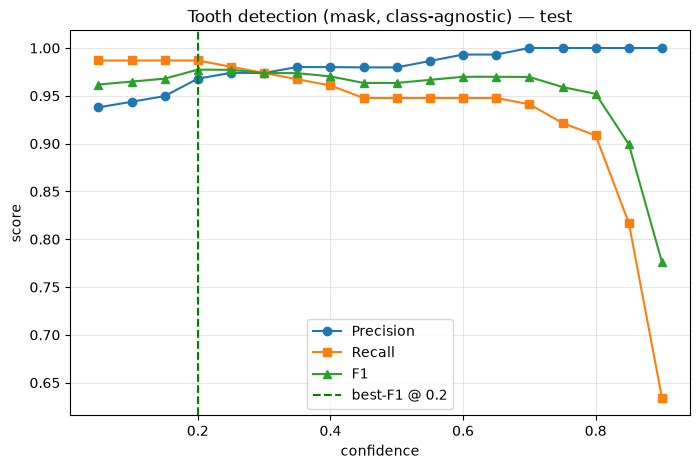

foreground Dice @conf 0.2: 92.8%
detect best-F1: P=96.8 R=98.7 F1=97.7 @conf=0.2
single-class tooth mode: numbering (exact-FDI/quadrant) metrics skipped — Dice + detection above are the score.


In [15]:
def rasterize(polys, W, H):
    m = np.zeros((H, W), np.uint8)
    for pts in polys:
        cv2.fillPoly(m, [pts.astype(np.int32)], 1)
    return m

def mask_iou(a, b):
    inter = np.logical_and(a, b).sum(); union = np.logical_or(a, b).sum()
    return inter / (union + 1e-9)

def dice(a, b):
    inter = np.logical_and(a, b).sum()
    return 2 * inter / (a.sum() + b.sum() + 1e-9)

test_imgs = sorted(glob.glob(os.path.join(CLEAN, "images", "test", "*")))
records = []   # per image: (pred_masks[list], pred_cls, pred_conf, gt_masks[list], gt_cls, (H,W))
for ip in tqdm(test_imgs, desc="segment test infer"):
    img = cv2.imread(ip); H, W = img.shape[:2]
    _, gpolys = load_seg("test", ip)
    gt_masks = [rasterize([p], W, H) for _, p in gpolys]
    gt_cls   = [c for c, _ in gpolys]
    res = best.predict(ip, imgsz=IMGSZ, conf=0.001, verbose=False, retina_masks=True)[0]
    p_masks, p_cls, p_conf = [], [], []
    if res.masks is not None:
        for poly, c, s in zip(res.masks.xy, res.boxes.cls.cpu().numpy().astype(int),
                              res.boxes.conf.cpu().numpy()):
            if len(poly) >= 3:
                p_masks.append(rasterize([np.asarray(poly)], W, H)); p_cls.append(int(c)); p_conf.append(float(s))
    records.append((p_masks, np.array(p_cls, int), np.array(p_conf, float), gt_masks,
                    np.array(gt_cls, int), (H, W)))

# foreground Dice at a moderate confidence
def foreground_dice(conf=0.25):
    ds = []
    for pm, pc, ps, gm, gc, (H, W) in records:
        pf = np.zeros((H, W), bool); gf = np.zeros((H, W), bool)
        for m, s in zip(pm, ps):
            if s >= conf: pf |= m.astype(bool)
        for m in gm: gf |= m.astype(bool)
        if gf.sum() == 0 and pf.sum() == 0: continue
        ds.append(dice(pf, gf))
    return float(np.mean(ds)) if ds else 0.0

def detect_sweep(conf, iou_thr=0.5):
    tp = fp = fn = 0
    for pm, pc, ps, gm, gc, _ in records:
        idx = [i for i in range(len(pm)) if ps[i] >= conf]
        idx.sort(key=lambda i: -ps[i])
        matched = np.zeros(len(gm), bool)
        for i in idx:
            best_j, best_iou = -1, 0.0
            for j in range(len(gm)):
                if matched[j]: continue
                v = mask_iou(pm[i], gm[j])
                if v > best_iou: best_iou, best_j = v, j
            if best_iou >= iou_thr: matched[best_j] = True; tp += 1
            else: fp += 1
        fn += int((~matched).sum())
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    return dict(conf=round(float(conf),3), tp=tp, fp=fp, fn=fn, precision=float(prec),
               recall=float(rec), f1=float(2*prec*rec/(prec+rec+1e-9)))

sweep = [detect_sweep(c) for c in np.round(np.arange(0.05, 0.91, 0.05), 2)]
best_f1 = max(sweep, key=lambda d: d["f1"])

def numbering_accuracy(conf, iou_thr=0.5):
    correct = quad = total = 0; confusion = Counter()
    for pm, pc, ps, gm, gc, _ in records:
        idx = [i for i in range(len(pm)) if ps[i] >= conf]; idx.sort(key=lambda i: -ps[i])
        matched = np.zeros(len(gm), bool)
        for i in idx:
            best_j, best_iou = -1, 0.0
            for j in range(len(gm)):
                if matched[j]: continue
                v = mask_iou(pm[i], gm[j])
                if v > best_iou: best_iou, best_j = v, j
            if best_iou >= iou_thr:
                matched[best_j] = True; total += 1
                gnm = CLASSES[int(gc[best_j])]; pnm = CLASSES[int(pc[i])]
                if pnm == gnm: correct += 1
                else: confusion[(gnm, pnm)] += 1
                if pnm[:1] == gnm[:1]: quad += 1
    return dict(matched=total, exact_acc=correct/max(total,1),
                quadrant_acc=quad/max(total,1), top_confusions=confusion.most_common(12))

fg_dice = foreground_dice(best_f1["conf"])
numbering = {"foreground_dice": fg_dice, "detect_sweep": sweep, "detect_best_f1": best_f1}
if not SINGLE_CLASS_TOOTH:                      # numbering is only meaningful with 52 FDI classes
    numbering["numbering_at_best_f1"] = numbering_accuracy(best_f1["conf"])
json.dump(numbering, open(os.path.join(WORK, "numbering_metrics.json"), "w"), indent=2, default=str)

cs = [d["conf"] for d in sweep]
plt.figure(figsize=(8,5))
plt.plot(cs, [d["precision"] for d in sweep], "o-", label="Precision")
plt.plot(cs, [d["recall"] for d in sweep], "s-", label="Recall")
plt.plot(cs, [d["f1"] for d in sweep], "^-", label="F1")
plt.axvline(best_f1["conf"], color="g", ls="--", label=f"best-F1 @ {best_f1['conf']}")
plt.xlabel("confidence"); plt.ylabel("score"); plt.title("Tooth detection (mask, class-agnostic) — test")
plt.legend(); plt.grid(alpha=0.3)
os.makedirs(os.path.join(WORK, "plots"), exist_ok=True)
plt.savefig(os.path.join(WORK, "plots", "detection_pr.png"), dpi=120, bbox_inches="tight"); plt.show()
print(f"foreground Dice @conf {best_f1['conf']}: {fg_dice*100:.1f}%")
print(f"detect best-F1: P={best_f1['precision']*100:.1f} R={best_f1['recall']*100:.1f} "
      f"F1={best_f1['f1']*100:.1f} @conf={best_f1['conf']}")
if SINGLE_CLASS_TOOTH:
    print("single-class tooth mode: numbering (exact-FDI/quadrant) metrics skipped — Dice + detection above are the score.")
else:
    nb_ = numbering["numbering_at_best_f1"]
    print(f"numbering (matched n={nb_['matched']}): exact FDI={nb_['exact_acc']*100:.1f}%  "
          f"quadrant={nb_['quadrant_acc']*100:.1f}%")
    for (g, p), nn in nb_["top_confusions"]:
        print(f"   {g} -> {p}: {nn}")

## 10 · Save annotated predictions (test + Validation-Public)
At the best-F1 confidence — annotated overlays plus a JSON of per-image detections. The 20
Validation-Public X-rays have no masks, so we save predictions only (useful for challenge review).

In [20]:
PRED_CONF = numbering["detect_best_f1"]["conf"]
def dump_predictions(img_paths, out_name):
    pred_dir = os.path.join(WORK, out_name); os.makedirs(pred_dir, exist_ok=True)
    dump = {}
    for ip in tqdm(img_paths, desc=out_name):
        res = best.predict(ip, imgsz=IMGSZ, conf=PRED_CONF, verbose=False, retina_masks=True)[0]
        cv2.imwrite(os.path.join(pred_dir, os.path.basename(ip)), res.plot())
        dets = []
        if res.boxes is not None:
            for c, s in zip(res.boxes.cls.cpu().numpy().astype(int), res.boxes.conf.cpu().numpy()):
                dets.append({"cls": CLASSES[int(c)], "conf": float(s)})
        dump[os.path.basename(ip)] = dets
    json.dump(dump, open(os.path.join(pred_dir, "_predictions.json"), "w"), indent=2)
    print("saved ->", pred_dir, f"({len(img_paths)} imgs, conf={PRED_CONF})")

dump_predictions(test_imgs, "predictions_test")
valpub = sorted(glob.glob(os.path.join(VALPUB, "*"))) if os.path.isdir(VALPUB) else []
if valpub: dump_predictions(valpub, "predictions_validation_public")

predictions_test:   0%|          | 0/5 [00:00<?, ?it/s]

saved -> /sts2d_seg_run/predictions_test (5 imgs, conf=0.2)


predictions_validation_public:   0%|          | 0/20 [00:00<?, ?it/s]

saved -> /sts2d_seg_run/predictions_validation_public (20 imgs, conf=0.2)


## 11 · Training graphs + qualitative check
Ultralytics writes `results.png` (loss/mAP curves), `confusion_matrix_normalized.png`, and mask PR
curves into the final run dir. Below, GT vs prediction on a few test X-rays.

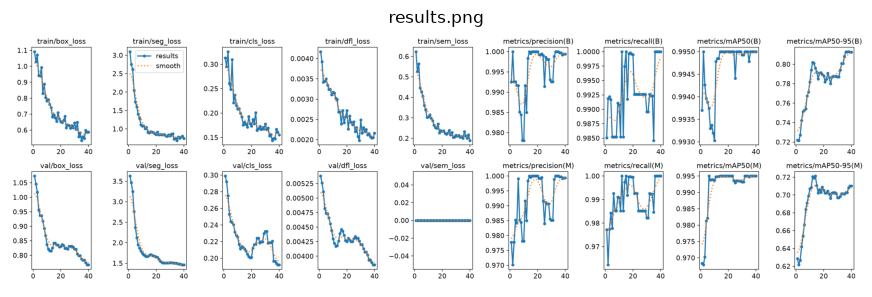

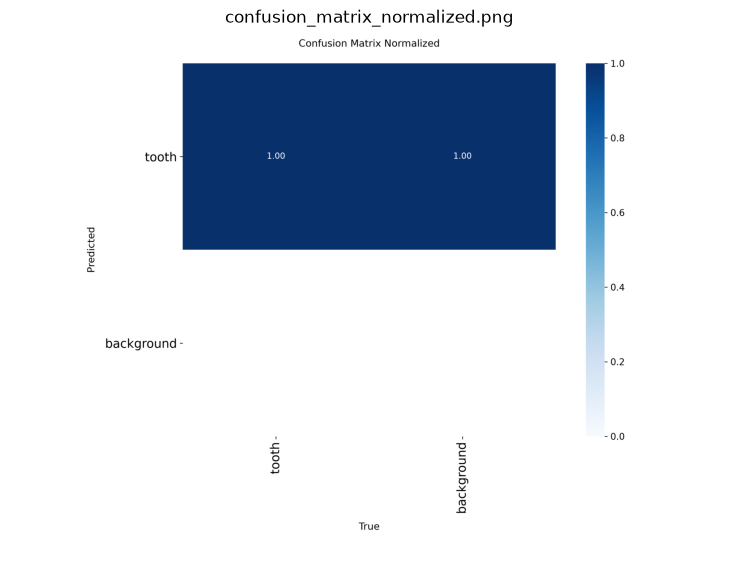

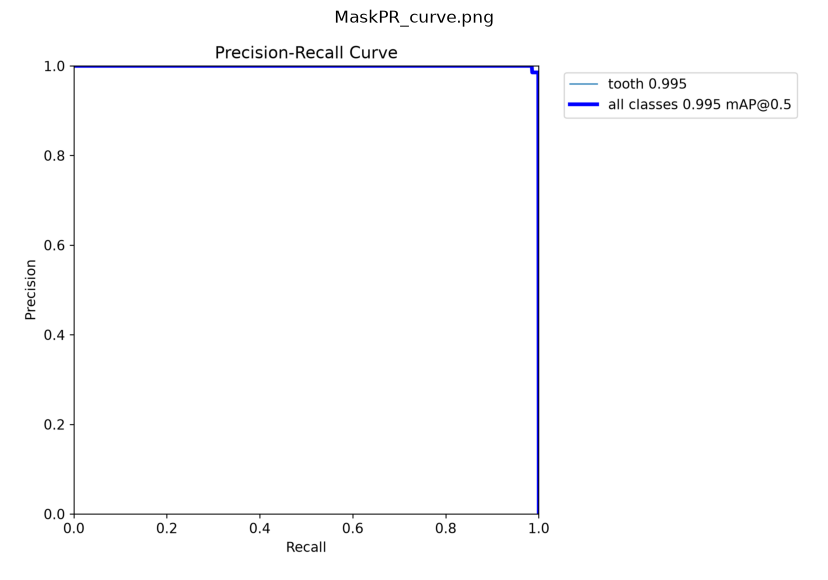

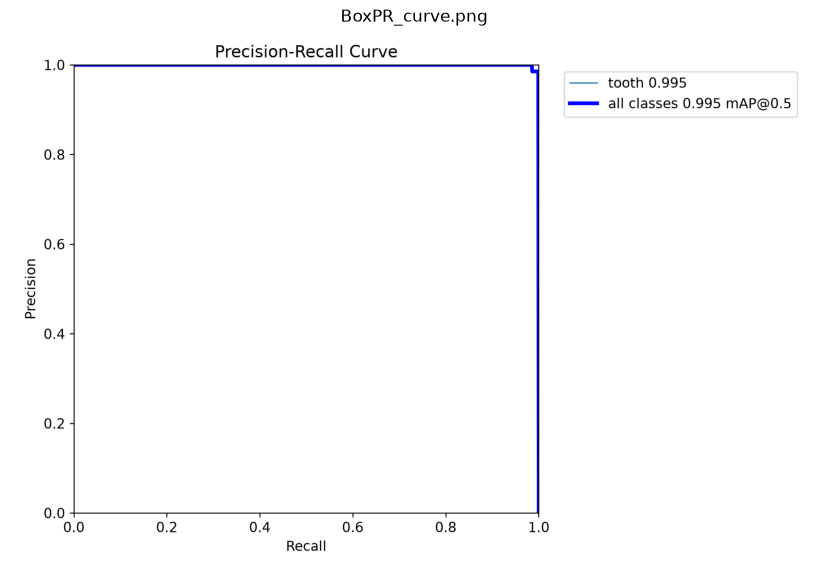

In [17]:
for fnm in ["results.png", "confusion_matrix_normalized.png", "MaskPR_curve.png", "BoxPR_curve.png"]:
    p = os.path.join(str(RUN_DIR), fnm)
    if os.path.exists(p):
        plt.figure(figsize=(11, 7)); plt.imshow(plt.imread(p)); plt.axis("off"); plt.title(fnm); plt.show()
    else:
        print("missing", p)

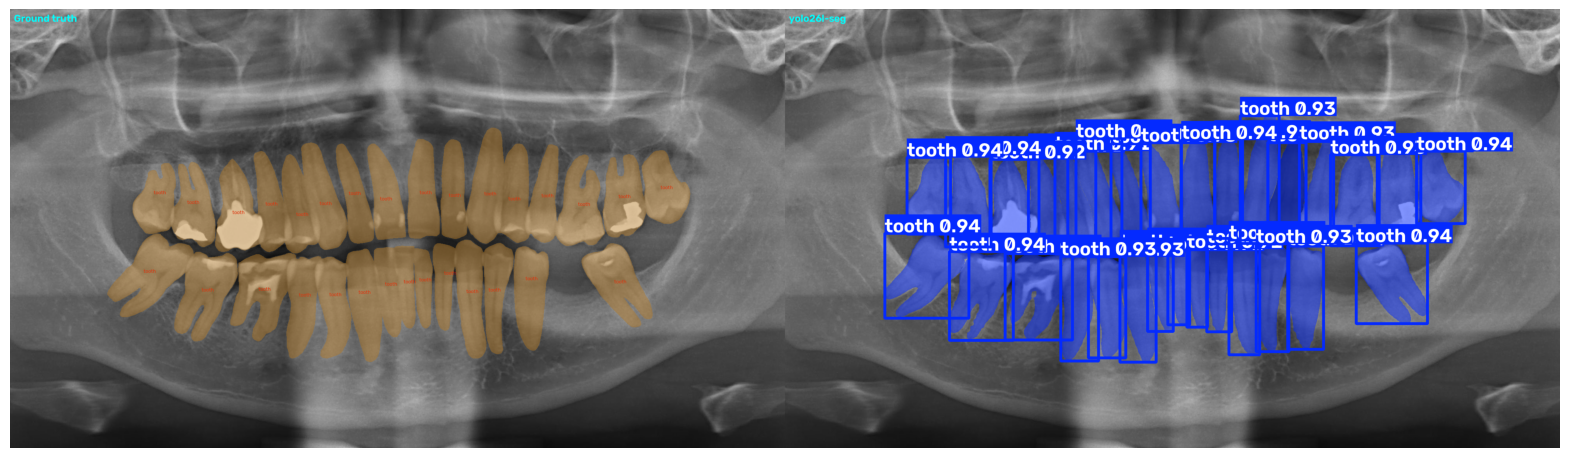

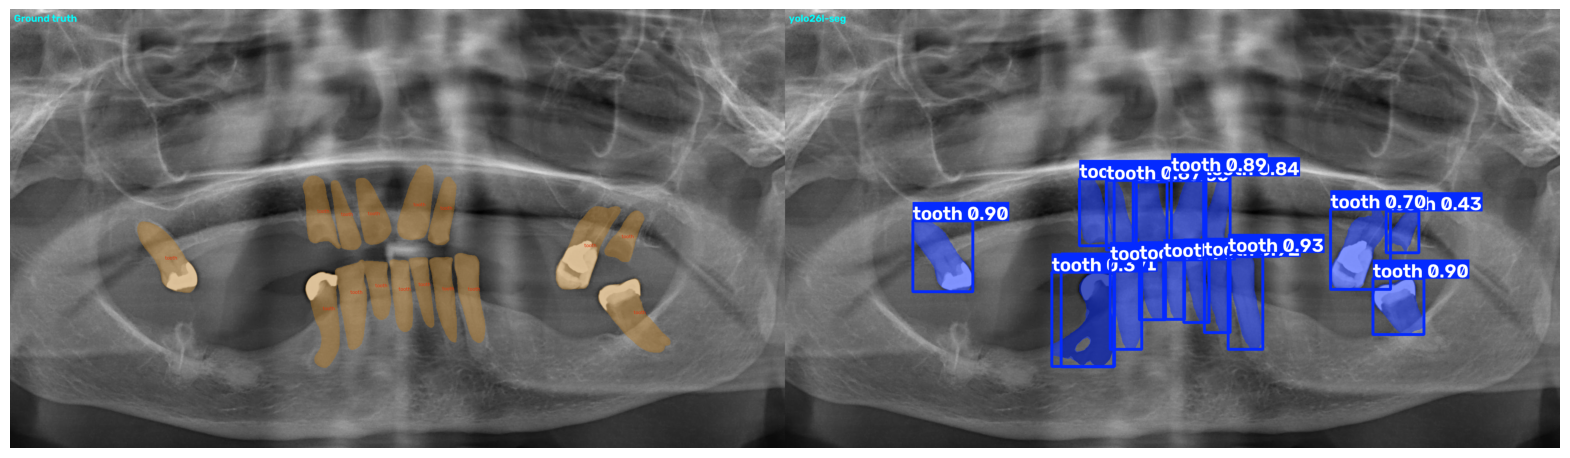

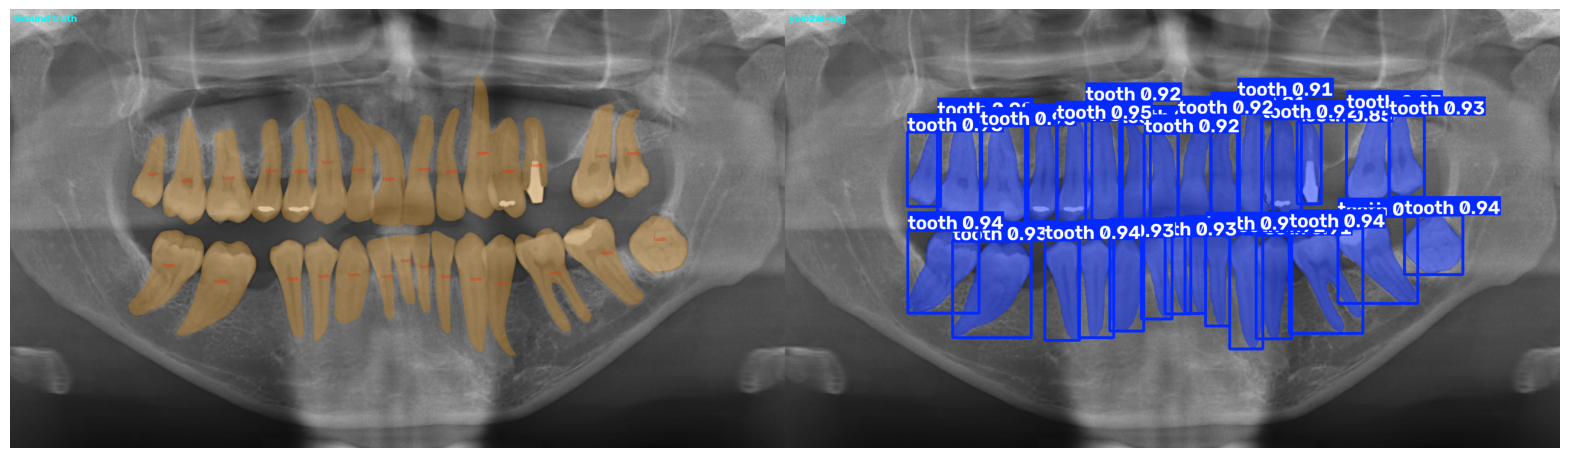

In [18]:
for ip in test_imgs[:3]:
    img, polys = load_seg("test", ip)
    gt = draw_seg(img, polys)
    res = best.predict(ip, imgsz=IMGSZ, conf=PRED_CONF, verbose=False, retina_masks=True)[0]
    pr = res.plot()
    cv2.putText(gt, "Ground truth", (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,0), 2)
    cv2.putText(pr, SEG_MODEL.replace('.pt',''), (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,0), 2)
    plt.figure(figsize=(20, 7))
    plt.imshow(np.hstack([cv2.cvtColor(gt, cv2.COLOR_BGR2RGB), cv2.cvtColor(pr, cv2.COLOR_BGR2RGB)]))
    plt.axis("off"); plt.show()

## 12 · Save the model + a results summary

In [19]:
shutil.copy2(BEST, os.path.join(WORK, "best.pt"))
summary = {"benchmark": "STS2D (YOLO-seg, semi-supervised)", "model": SEG_MODEL,
           "task": ("STS24 2D panoramic TOOTH segmentation (1 class)" if SINGLE_CLASS_TOOTH
                    else "STS24 2D panoramic teeth segmentation (FDI, 52 classes)"),
           "single_class_tooth": bool(SINGLE_CLASS_TOOTH),
           "imgsz": IMGSZ, "batch": BATCH, "semi_supervised": bool(SEMI_SUPERVISED and PSEUDO_TXT),
           "epochs_stage1": EPOCHS_STAGE1, "epochs_stage2": EPOCHS_STAGE2,
           "classes": CLASSES, "augmentation": AUG,
           "test_metrics": test_metrics,
           "numbering": {k: v for k, v in numbering.items() if k != "detect_sweep"},
           "artifacts": {"weights": os.path.join(WORK, "best.pt"),
                         "test_metrics": os.path.join(WORK, "test_metrics.json"),
                         "numbering_metrics": os.path.join(WORK, "numbering_metrics.json"),
                         "predictions_test": os.path.join(WORK, "predictions_test"),
                         "run_dir": str(RUN_DIR)}}
json.dump(summary, open(os.path.join(WORK, "summary.json"), "w"), indent=2, default=str)
print(json.dumps(summary["test_metrics"], indent=2))
print(json.dumps(summary["numbering"], indent=2, default=str))
print("\nAll artifacts under:", WORK)
for p in sorted(glob.glob(os.path.join(WORK, "*"))):
    print("  ", os.path.basename(p))

{
  "model": "yolo26l-seg.pt",
  "weights": "/sts2d_seg_run/sts2d/stage2_finetune_labeled/weights/best.pt",
  "imgsz": 960,
  "mask_map50": 0.9936707668867255,
  "mask_map50_95": 0.7000600762151097,
  "box_map50": 0.994135842351801,
  "box_map50_95": 0.7668528302785649,
  "per_class": {
    "tooth": {
      "mask_AP50-95": 0.7000600762151097
    }
  }
}
{
  "foreground_dice": 0.9280281182698003,
  "detect_best_f1": {
    "conf": 0.2,
    "tp": 151,
    "fp": 5,
    "fn": 2,
    "precision": 0.9679487179425132,
    "recall": 0.9869281045687129,
    "f1": 0.9773462778108732
  }
}

All artifacts under: /sts2d_seg_run
   best.pt
   dataset_sts2d_seg
   download
   eda_overview.png
   numbering_metrics.json
   plots
   predictions_test
   predictions_validation_public
   pseudo_labels
   stage1_best.pt
   stage1_last.pt
   stage2_best.pt
   stage2_last.pt
   sts2d
   summary.json
   test_metrics.json


## 13 · Notes & levers
**Implemented (the STS2D benchmark, exactly)**
1. **YOLO26x-seg** segmentation — STS2D-master's YOLOv8x-seg bumped to YOLO26x-seg (NMS-free
   end-to-end) so it runs natively on RTX PRO 6000 / Blackwell. Same architecture family/recipe. ✅
2. **Semi-supervised two-stage recipe** — Stage 1 `train_model` on ALL data (labeled + 2 350
   provided pseudo-labels), Stage 2 `finetune_model` on labeled only. ✅
3. **Task toggle `SINGLE_CLASS_TOOTH`** — `True` = one "tooth" class (STS-2D Dice metric; easier,
   faster, lighter, flips ON); `False` = 52-class FDI numbering (flips OFF). Pseudo-labels are
   remapped to class 0 on the fly in tooth mode. ✅
4. **52-class FDI scheme sorted as integers** — matches the provided pseudo-labels byte-for-byte
   (verified `18`=7, `28`=15, `38`=23, `48`=31, `51`=32). ✅
5. **Flip behaviour follows the task** — `fliplr=0.5` (tooth mode, safe augmentation) vs `0.0` (FDI
   mode, positional labels). Mosaic kept (transforms polygons with the pixels), closed for finetune. ✅
6. **Per-epoch report + best/last every epoch** (`save_period=1`, epoch callback). ✅
7. **STS-style evaluation** — mask mAP + foreground **Dice** (+ exact-FDI/quadrant in FDI mode). ✅

**Push higher if needed**
* Raise `IMGSZ` (1024 → 1280) if small third molars/roots are missed — panoramics are wide.
* Loop Stage 1 ↔ pseudo-label refresh: re-predict the unlabeled set with the Stage-2 model, rewrite
  the pseudo-labels, retrain (classic self-training — how STS2D climbs the leaderboard).
* `top_confusions` shows neighbour (`14↔15`) vs wrong-side (`14↔24`) numbering errors.

**Caveats**
* Local metrics use a **held-out slice of the 30 labeled X-rays** (`SPLIT_FRACS`) because the real
  `Testset` masks are held by the organizers — the official score comes from their server.
* STS2D-master pins ultralytics 8.0.45; we run a current build for Blackwell + **YOLO26x-seg**
  (`PIN_OLD_ULTRALYTICS` reverts to the 8.0.45 pin, which auto-falls-back to YOLOv8x-seg since it
  has no YOLO26). Ultralytics weights are AGPL-3.0 — check licensing for your use.